## Imports

In [1]:
import xarray as xr

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from xhistogram.xarray import histogram
import matplotlib.colors as colors
import cartopy.crs as ccrs
import scipy
import matplotlib.patches as patches

## Open the data

In [3]:
# data in persistent bucket
#target_url ='gs://leap-scratch/cspencerjones/hero-calc/masked_hist.zarr'



###target_url ='gs://leap-persistent/cspencerjones/hero-calc/compute/llc4320/masked_hist_48hr.zarr'
#target_url ='gs://leap-persistent/cspencerjones/hero-calc/compute/llc4320/masked_hist_renorm_48hr.zarr'

target_url ='gs://leap-persistent/cspencerjones/hero-calc/masked_hist_renorm_3hr.zarr'
#target_url2 = 'gs://leap-persistent/tomnicholas/hero-calc/compute/llc4320/vort_strain_div_histogram_coarsen_nan_padding_3_hourly.zarr'

In [4]:
hist_ds = xr.open_dataset(target_url, engine="zarr", chunks={})
#hist_ds2 = xr.open_dataset(target_url2, engine="zarr", chunks={})

In [5]:
hist_ds['histogram_vort_strain_div'].isel(time=0).nbytes / 1e9

1.678950504

In [6]:
hist_ds

<xarray.Dataset> Size: 62GB
Dimensions:                    (time: 37, region: 437, vort_bin: 99,
                                strain_bin: 49, div_bin: 99, vertices: 4)
Coordinates:
  * time                       (time) datetime64[ns] 296B 2011-09-17T22:30:00...
  * vort_bin                   (vort_bin) float64 792B -4.949 -4.848 ... 4.949
  * strain_bin                 (strain_bin) float64 392B 0.05102 ... 4.949
  * div_bin                    (div_bin) float64 792B -4.949 -4.848 ... 4.949
    j_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_longitude         (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
    region_num                 (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    i_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    face                       (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_latitude          (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
Dimensions without coordinates: region, vertices
Data variables:
    histogram_vort_strain_div  (time, region, vort_bin, strain_bin, div_bin) float64 62GB dask.array<chunksize=(1, 1, 99, 49, 99), meta=np.ndarray>

In [7]:
from xarray.indexes import PandasIndex

# have to add the index ourselves manually for some reason
hist_ds = hist_ds.set_xindex('region_num', PandasIndex)
#hist_ds2 = hist_ds2.set_xindex('region_num', PandasIndex)

In [8]:
hist_ds

<xarray.Dataset> Size: 62GB
Dimensions:                    (time: 37, region: 437, vort_bin: 99,
                                strain_bin: 49, div_bin: 99, vertices: 4)
Coordinates:
  * time                       (time) datetime64[ns] 296B 2011-09-17T22:30:00...
  * vort_bin                   (vort_bin) float64 792B -4.949 -4.848 ... 4.949
  * strain_bin                 (strain_bin) float64 392B 0.05102 ... 4.949
  * div_bin                    (div_bin) float64 792B -4.949 -4.848 ... 4.949
    j_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_longitude         (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
  * region_num                 (region) int64 3kB 4 5 6 7 13 ... 792 793 798 799
    i_region_coarse            (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    face                       (region) int64 3kB dask.array<chunksize=(437,), meta=np.ndarray>
    vertices_latitude          (vertices, region) float32 7kB dask.array<chunksize=(4, 437), meta=np.ndarray>
Dimensions without coordinates: region, vertices
Data variables:
    histogram_vort_strain_div  (time, region, vort_bin, strain_bin, div_bin) float64 62GB dask.array<chunksize=(1, 1, 99, 49, 99), meta=np.ndarray>

## Correct PDF normalization

Division by 80 comes from 8 samples per day (3-hourly sampling of hourly data) over a 10-day period. 
This correction is currently required because I accidentally did `coarsen(time=8*10).sum(dim='time')` instead of `coarsen(time=8*10).mean(dim='time')` before saving to zarr.

In [9]:
#hist_ds2['histogram_vort_strain_div'] = hist_ds2['histogram_vort_strain_div'] / 80

In [10]:
hist_ds['histogram_vort_strain_div'].isel(time=slice(11,20)).time

<xarray.DataArray 'time' (time: 9)> Size: 72B
array(['2012-01-05T22:30:00.000000000', '2012-01-15T22:30:00.000000000',
       '2012-01-25T22:30:00.000000000', '2012-02-04T22:30:00.000000000',
       '2012-02-14T22:30:00.000000000', '2012-02-24T22:30:00.000000000',
       '2012-03-05T22:30:00.000000000', '2012-03-15T22:30:00.000000000',
       '2012-03-25T22:30:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 72B 2012-01-05T22:30:00 ... 2012-03-25T22:...

## Basic quantities

In [11]:
#JFM
h = hist_ds['histogram_vort_strain_div'].isel(time=slice(11,20))
h['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h['center_lon'] = h['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1 = h.mean('time')

#ASO
h_ASO = hist_ds['histogram_vort_strain_div'].roll(time=5,roll_coords=True).isel(time=slice(0,10))
h_ASO['center_lat'] = hist_ds.vertices_latitude.mean('vertices')
h_ASO['center_lon'] = hist_ds.vertices_longitude.mean('vertices')
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
h_ASO['center_lon'] = h_ASO['center_lon'].where(max_vert<100,((hist_ds.vertices_longitude.where(max_vert>100).min('vertices') +hist_ds.vertices_longitude.where(max_vert>100).max('vertices')+360)/2))
h1_ASO = h_ASO.mean('time')

In [12]:
right_half = (h1*h1.div_bin).where(h1.div_bin<0).isel(vort_bin=slice(50,100)).sum(['vort_bin','div_bin','strain_bin']).load()
total = (h1*h1.div_bin).where(h1.div_bin<0).sum(['vort_bin','div_bin','strain_bin']).load()

#put 50% of the vorticity in the zero bin into righthalf_plus
righthalf_plus = right_half + (h1*h1.div_bin).where(h1.div_bin<0).isel(vort_bin=49).sum(['div_bin','strain_bin']).load()/2

right_half_ASO = (h1_ASO*h1_ASO.div_bin).where(h1_ASO.div_bin<0).isel(vort_bin=slice(50,100)).sum(['vort_bin','div_bin','strain_bin']).load()
total_ASO = (h1_ASO*h1_ASO.div_bin).where(h1_ASO.div_bin<0).sum(['vort_bin','div_bin','strain_bin']).load()

righthalfASO_plus = right_half_ASO + (h1_ASO*h1_ASO.div_bin).where(h1_ASO.div_bin<0).isel(vort_bin=49).sum(['div_bin','strain_bin']).load()/2

KeyboardInterrupt: 

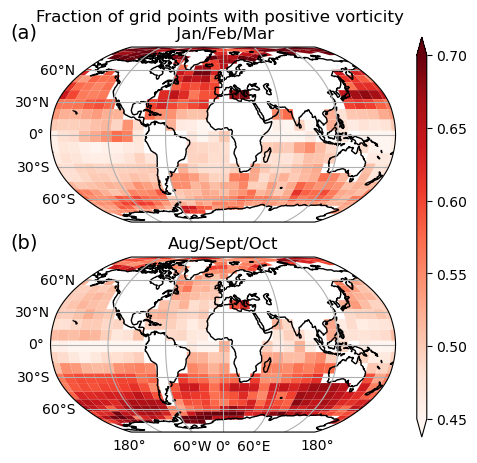

In [13]:
fig = plt.figure(figsize=(5, 5))
plt.clf()
ax = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalf_plus/total, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
ax.autoscale_view
#plt.colorbar(coll)
ax.gridlines(draw_labels=["left"])
plt.text(-2.1*10**7,0.95*10**7,'(a)',fontsize=14)
plt.title('Fraction of grid points with positive vorticity \n Jan/Feb/Mar')

ax3 = fig.add_subplot(2, 1, 2, projection=ccrs.Robinson())

ax3.set_global()

ax3.coastlines()

max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalfASO_plus/total_ASO, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax3.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
#ax2.autoscale_view
#plt.colorbar(coll)
ax3.gridlines(draw_labels=["bottom", "left"])
ax3.text(-2.1*10**7,0.95*10**7,'(b)',fontsize=14)
plt.title('Aug/Sept/Oct')


cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.8])
fig.colorbar(coll, cax=cbar_ax,extend='both')

plt.savefig('Frac-positive-vort.png')

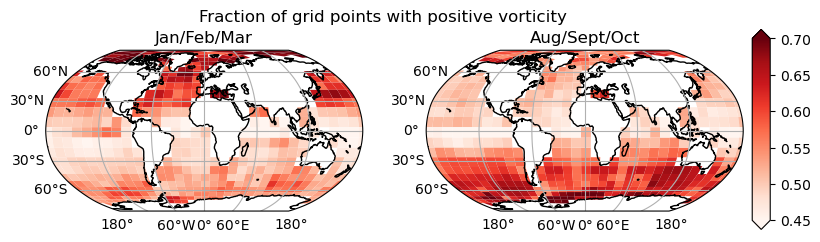

In [14]:
#poster_version
fig = plt.figure(figsize=(9, 2.5))
plt.clf()

ax = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalf_plus/total, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
ax.autoscale_view
#plt.colorbar(coll)
ax.gridlines(draw_labels=["bottom", "left"])
#plt.text(-2.1*10**7,0.95*10**7,'(a)',fontsize=14)
plt.title('Jan/Feb/Mar')

ax3 = fig.add_subplot(1, 2, 2, projection=ccrs.Robinson())

ax3.set_global()

ax3.coastlines()

max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=righthalfASO_plus/total_ASO, cmap='Reds', edgecolors='none', transform=ccrs.PlateCarree())
ax3.add_collection(coll)
coll.set_clim(vmin=0.45,vmax=0.7)
#ax2.autoscale_view
#plt.colorbar(coll)
ax3.gridlines(draw_labels=["bottom", "left"])
#ax3.text(-2.1*10**7,0.95*10**7,'(b)',fontsize=14)
plt.title('Aug/Sept/Oct')

plt.suptitle('Fraction of grid points with positive vorticity') 


cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
fig.colorbar(coll, cax=cbar_ax,extend='both')

plt.savefig('Frac-positive-vort-poster.png')

In [13]:
hi_strain = (h1*h1.div_bin).where(h1.strain_bin>(np.abs(h1.vort_bin)+1.5)).sum(['vort_bin','div_bin','strain_bin']).load()
hi_strain_ASO = (h1_ASO*h1_ASO.div_bin).where(h1_ASO.strain_bin>(np.abs(h1_ASO.vort_bin)+1.5)).sum(['vort_bin','div_bin','strain_bin']).load()

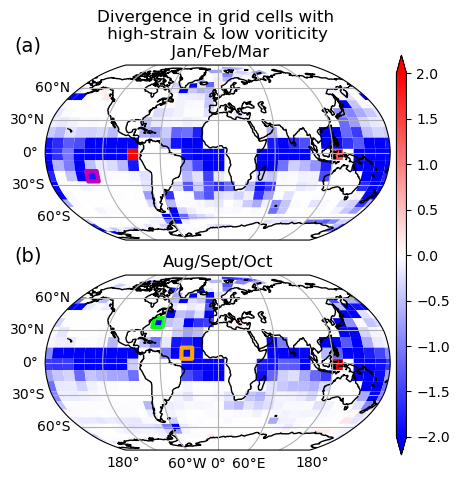

In [15]:
fig = plt.figure(figsize=(5, 5))
plt.clf()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)

ax2 = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson())

ax2.set_global()

ax2.coastlines()

coll = PolyCollection(verts, array=hi_strain, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax2.add_collection(coll)
coll.set_clim(-2,vmax=2)
ax2.autoscale_view
#plt.colorbar(coll)
ax2.gridlines(draw_labels=["left"])
plt.text(-2*10**7,10**7,'(a)',fontsize=14)
plt.title('Divergence in grid cells with \n high-strain & low voriticity \n Jan/Feb/Mar')



#col2 = PolyCollection(verts[43:44], array=hi_strain_ASO[43:44], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
col2 = PolyCollection(verts[282:283], array=hi_strain_ASO[282:283], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax2.add_collection(col2)
ax2.autoscale_view()



ax4 = fig.add_subplot(2, 1, 2, projection=ccrs.Robinson())

ax4.set_global()

ax4.coastlines()


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hi_strain_ASO, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax4.add_collection(coll)
coll.set_clim(vmin=-2,vmax=2)
#ax2.autoscale_view
#plt.colorbar(coll)
ax4.gridlines(draw_labels=["bottom", "left"])
ax4.text(-2*10**7,10**7,'(b)',fontsize=14)
plt.title('Aug/Sept/Oct')

col2 = PolyCollection(verts[350:351], array=hi_strain_ASO[350:351], facecolors='none', linewidths=3, edgecolors='lime', transform=ccrs.PlateCarree())
ax4.add_collection(col2)
ax4.autoscale_view()

col2 = PolyCollection(verts[30:31], array=hi_strain_ASO[30:31], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax4.add_collection(col2)
ax4.autoscale_view()


#col2 = PolyCollection(verts[228:229], array=hi_strain_ASO[228:229], facecolors='none', linewidths=3, edgecolors='yellow', transform=ccrs.PlateCarree())
#ax4.add_collection(col2)
#ax4.autoscale_view()

cbar_ax = fig.add_axes([0.87, 0.1, 0.02, 0.8])
fig.colorbar(coll, cax=cbar_ax,extend='both')

plt.savefig('Div-hi-strain-map.png')

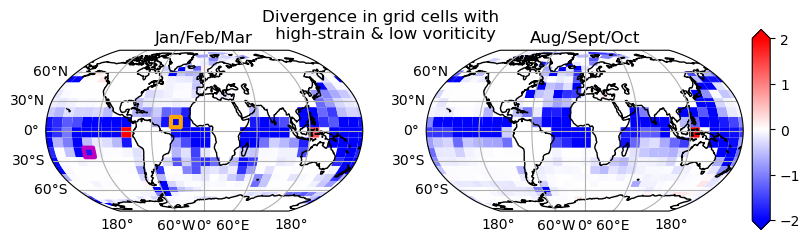

In [33]:
#poster_version
fig = plt.figure(figsize=(9, 2.5))
plt.clf()


from matplotlib.collections import PolyCollection
#fig, ax = plt.subplots()
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)

ax2 = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())

ax2.set_global()

ax2.coastlines()

coll = PolyCollection(verts, array=hi_strain, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax2.add_collection(coll)
coll.set_clim(-2,vmax=2)
ax2.autoscale_view
#plt.colorbar(coll)
ax2.gridlines(draw_labels=["bottom","left"])
#plt.text(-2*10**7,10**7,'(a)',fontsize=14)
plt.title('Jan/Feb/Mar')

col2 = PolyCollection(verts[30:31], array=hi_strain_ASO[30:31], facecolors='none', linewidths=3, edgecolors='orange', transform=ccrs.PlateCarree())
ax2.add_collection(col2)
ax2.autoscale_view()

#col2 = PolyCollection(verts[43:44], array=hi_strain_ASO[43:44], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
col2 = PolyCollection(verts[282:283], array=hi_strain_ASO[282:283], facecolors='none', linewidths=3, edgecolors='m', transform=ccrs.PlateCarree())
ax2.add_collection(col2)
ax2.autoscale_view()


ax4 = fig.add_subplot(1, 2, 2, projection=ccrs.Robinson())

ax4.set_global()

ax4.coastlines()


# Make the collection and add it to the plot.
coll = PolyCollection(verts, array=hi_strain_ASO, cmap='bwr', edgecolors='none', transform=ccrs.PlateCarree())
ax4.add_collection(coll)
coll.set_clim(vmin=-2,vmax=2)
#ax2.autoscale_view
#plt.colorbar(coll)
ax4.gridlines(draw_labels=["bottom", "left"])
#ax4.text(-2*10**7,10**7,'(b)',fontsize=14)
plt.title('Aug/Sept/Oct')

#col2 = PolyCollection(verts[350:351], array=hi_strain_ASO[350:351], facecolors='none', linewidths=3, edgecolors='lime', transform=ccrs.PlateCarree())
#ax4.add_collection(col2)
#ax4.autoscale_view()


#col2 = PolyCollection(verts[228:229], array=hi_strain_ASO[228:229], facecolors='none', linewidths=3, edgecolors='yellow', transform=ccrs.PlateCarree())
#ax4.add_collection(col2)
#ax4.autoscale_view()

plt.suptitle('Divergence in grid cells with \n high-strain & low voriticity')

cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
fig.colorbar(coll, cax=cbar_ax,extend='both')

plt.savefig('Div-hi-strain-map-poster.png')